In [1]:
!pip install gymnasium

In [14]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
env = gym.make("CartPole-v1")
state,_ = env.reset()
print("Initial State:",state)
print("State Shape:",env.observation_space.shape)
print("Action shape:",env.action_space)

Initial State: [-0.0028652   0.01329524 -0.02549713 -0.01172365]
State Shape: (4,)
Action shape: Discrete(2)


In [16]:
episodes = 10
rewards = []
for episode in range(episodes):
  state,_ = env.reset()
  total_reward = 0
  done = False
  while not done:
    action = env.action_space.sample()
    state,reward,terminated,truncated,_ = env.step(action)
    done = terminated or truncated
    total_reward += reward
  rewards.append(total_reward)
print("Average Random Reward:",np.mean(rewards))

Average Random Reward: 16.7


**Applying Q-learning**

In [17]:
#Creating Discreating  Function as Q-learning needs discretize state space

bins = [20,20,20,20]
obs_space_high = env.observation_space.high
obs_space_low = env.observation_space.low

obs_space_high[1] = 5
obs_space_high[3] = 5
obs_space_low[1] = -5
obs_space_low[3] = -5

def discretize(state):
  ratios = (state-obs_space_low)/(obs_space_high - obs_space_low)
  new_obs = (ratios*bins).astype(int)
  new_obs = np.clip(new_obs,0,np.array(bins)-1)
  return tuple(new_obs)

In [18]:
q_table = np.zeros(bins+[env.action_space.n])

In [19]:
import random

In [20]:
episodes = 5000
learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

reward_list = []
for episode in range(episodes):
  state,_ = env.reset()
  state = discretize(state)
  total_reward = 0
  done = False

  while not done:
    if random.uniform(0,1)<epsilon:
      action = env.action_space.sample()
    else:
      action = np.argmax(q_table[state])
    next_state,reward,terminated,truncated,_ = env.step(action)
    done = terminated or truncated
    next_state = discretize(next_state)
    best_future_q = np.max(q_table[next_state])
    current_q = q_table[state+(action,)]
    q_table[state+(action,)] = current_q + learning_rate * (reward+gamma*best_future_q - current_q)
    state = next_state
    total_reward += reward
  epsilon = max(min_epsilon,epsilon*epsilon_decay)
  reward_list.append(total_reward)

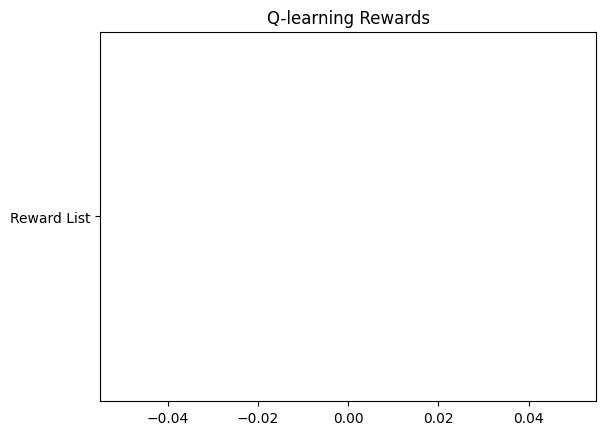

In [21]:
plt.plot("Reward List")
plt.title("Q-learning Rewards")
plt.show()

In [22]:
print(len(reward_list))
print(reward_list[:10])

5000
[28.0, 16.0, 20.0, 21.0, 11.0, 15.0, 17.0, 17.0, 13.0, 40.0]


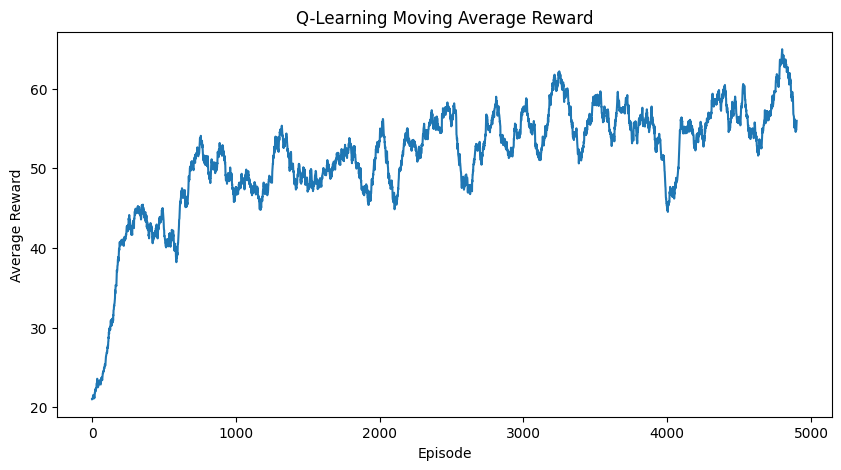

In [24]:
window = 100
moving_avg = np.convolve(reward_list, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(moving_avg)
plt.title("Q-Learning Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.show()

**DQN**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

In [25]:
env = gym.make("CartPole-v1")

In [26]:
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

In [27]:
print("State size:",state_size)
print("Action size:",action_size)

State size: 4
Action size: 2


In [36]:
class DQN(nn.Module):
  def __init__(self,state_size,action_size):
    super(DQN,self).__init__()
    self.fc1 = nn.Linear(state_size,128)
    self.fc2 = nn.Linear(128,128)
    self.fc3 = nn.Linear(128,action_size)

  def forward(self,x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    return self.fc3(x)

In [37]:
model = DQN(state_size,action_size)
optimizer = optim.Adam(model.parameters(),lr=0.001)
loss_fn = nn.MSELoss()

In [38]:
memory = deque(maxlen=100000)
def remember(state,action,reward,next_state,done):
  memory.append((state,action,reward,next_state,done))

In [39]:
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
def choose_action(state):
  if random.random()<epsilon:
    return random.randrange(action_size)
  state = torch.FloatTensor(state)
  q_values = model(state)
  return torch.argmax(q_values).item()

In [40]:
def replay(batch_size):
  if len(memory)<batch_size:
    return
    batch = random.sample(memory,batch_size)
    for state,action,reward,next_state,done in batch:
      state = torch.FloatTensor(state)
      next_state = torch.FloatTensor(next_state)
      target = reward
      if not done:
        target += 0.99*torch.max(model(next_state)).item()
      current_q = model(state)[action]
      loss = loss_fn(current_q,torch.tensor(target))
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

In [41]:
episodes = 500
reward_list = []
for episode in range(episodes):
  state,_ = env.reset()
  total_reward = 0
  done = False
  while not done:
    action = choose_action(state)
    next_state,reward,terminated,truncated,_ = env.step(action)
    done = terminated or truncated
    remember(state,action,reward,next_state,done)
    state = next_state
    replay(32)
    total_reward += reward
  global epsilon
  epsilon = max(epsilon_min,epsilon*epsilon_decay)
  reward_list.append(total_reward)
  if episode %50 ==0:
    print(f"Episode {episode}, Reward: {total_reward}")

Episode 0, Reward: 21.0
Episode 50, Reward: 13.0
Episode 100, Reward: 9.0
Episode 150, Reward: 10.0
Episode 200, Reward: 20.0
Episode 250, Reward: 11.0
Episode 300, Reward: 9.0
Episode 350, Reward: 11.0
Episode 400, Reward: 8.0
Episode 450, Reward: 9.0


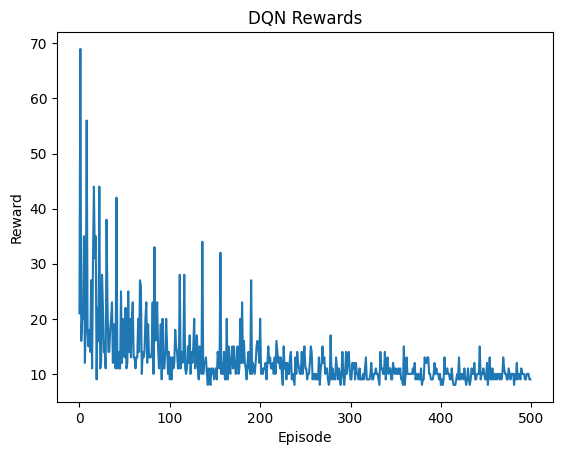

In [42]:
plt.plot(reward_list)
plt.title("DQN Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()